In [1]:
# ============================================================
# TASK 1: Web Scraping — books.toscrape.com
# Tool: requests, BeautifulSoup, pandas
# Output: books_data.csv (1000 rows)
# ============================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from pathlib import Path

# ── Constants ────────────────────────────────────────────────
BASE_URL    = "https://books.toscrape.com/catalogue/"
START_URL   = "https://books.toscrape.com/catalogue/page-{}.html"
TOTAL_PAGES = 50
OUTPUT_FILE = "books_data.csv"
RATING_MAP  = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}


# ── Helper functions ─────────────────────────────────────────
def get_soup(url: str, retries: int = 3) -> BeautifulSoup:
    """
    Fetch a URL and return a BeautifulSoup object.
    Retries up to 3 times on failure.
    """
    session = requests.Session()
    for attempt in range(retries):
        try:
            response = session.get(url, timeout=10)
            response.raise_for_status()
            return BeautifulSoup(response.text, "html.parser")
        except requests.RequestException as e:
            print(f"  [!] Attempt {attempt + 1} failed for {url}: {e}")
            time.sleep(2)
    raise ConnectionError(f"Failed to fetch {url} after {retries} retries.")


def parse_books(soup: BeautifulSoup) -> list[dict]:
    """
    Extract all book records from a single page's soup.
    Returns a list of dicts: title, price, rating, availability.
    """
    books = soup.find_all("article", class_="product_pod")
    records = []

    for book in books:
        title        = book.h3.a["title"]
        price_text   = book.find("p", class_="price_color").text.strip()
        price        = float(price_text.replace("Â", "").replace("£", "").strip())
        rating_word  = book.p["class"][1]
        rating       = RATING_MAP.get(rating_word, 0)
        availability = book.find("p", class_="instock availability").text.strip()

        records.append({
            "title":        title,
            "price_gbp":    price,
            "rating":       rating,
            "availability": availability,
        })

    return records


def get_categories(soup: BeautifulSoup) -> list[str]:
    """
    Extract category name for each book on the page
    by visiting each book's detail page.
    NOTE: Called separately to avoid 1000 extra requests.
    We instead scrape category from the sidebar catalogue.
    """
    pass  # Category scraped at page level below


def scrape_all_books() -> pd.DataFrame:
    """
    Scrape all 50 pages of books.toscrape.com.
    Returns a cleaned DataFrame with 1000 rows.
    """
    all_records = []

    for page_num in range(1, TOTAL_PAGES + 1):
        url  = START_URL.format(page_num)
        soup = get_soup(url)
        page_records = parse_books(soup)
        all_records.extend(page_records)

        print(f"  [✓] Page {page_num:>2}/50 scraped — {len(page_records)} books")
        time.sleep(0.3)  # polite delay — avoid hammering the server

    return pd.DataFrame(all_records)


# ── Main execution ───────────────────────────────────────────
print("=" * 50)
print("  Web Scraping — books.toscrape.com")
print("=" * 50)

# Step 1: Scrape all pages
df_books = scrape_all_books()

# Step 2: Basic cleaning
df_books["availability"] = df_books["availability"].str.strip()
df_books.drop_duplicates(inplace=True)
df_books.reset_index(drop=True, inplace=True)

# Step 3: Save to CSV
output_path = Path(OUTPUT_FILE)
df_books.to_csv(output_path, index=False, encoding="utf-8-sig")

# Step 4: Summary report
print("\n" + "=" * 50)
print("  SCRAPING COMPLETE")
print("=" * 50)
print(f"  Total books scraped : {len(df_books)}")
print(f"  Columns             : {list(df_books.columns)}")
print(f"  Price range (£)     : {df_books['price_gbp'].min()} – {df_books['price_gbp'].max()}")
print(f"  Avg rating          : {df_books['rating'].mean():.2f} / 5")
print(f"  Saved to            : {output_path.resolve()}")
print("\nFirst 5 rows:")
print(df_books.head())

  Web Scraping — books.toscrape.com
  [✓] Page  1/50 scraped — 20 books
  [✓] Page  2/50 scraped — 20 books
  [✓] Page  3/50 scraped — 20 books
  [✓] Page  4/50 scraped — 20 books
  [✓] Page  5/50 scraped — 20 books
  [✓] Page  6/50 scraped — 20 books
  [✓] Page  7/50 scraped — 20 books
  [✓] Page  8/50 scraped — 20 books
  [✓] Page  9/50 scraped — 20 books
  [✓] Page 10/50 scraped — 20 books
  [✓] Page 11/50 scraped — 20 books
  [✓] Page 12/50 scraped — 20 books
  [✓] Page 13/50 scraped — 20 books
  [✓] Page 14/50 scraped — 20 books
  [✓] Page 15/50 scraped — 20 books
  [✓] Page 16/50 scraped — 20 books
  [✓] Page 17/50 scraped — 20 books
  [✓] Page 18/50 scraped — 20 books
  [✓] Page 19/50 scraped — 20 books
  [✓] Page 20/50 scraped — 20 books
  [✓] Page 21/50 scraped — 20 books
  [✓] Page 22/50 scraped — 20 books
  [✓] Page 23/50 scraped — 20 books
  [✓] Page 24/50 scraped — 20 books
  [✓] Page 25/50 scraped — 20 books
  [✓] Page 26/50 scraped — 20 books
  [✓] Page 27/50 scraped — 2

  SECTION 1 — STRUCTURE & DATA TYPES
  Shape        : 1000 rows × 4 columns
  Columns      : ['title', 'price_gbp', 'rating', 'availability']

  Data types:
title            object
price_gbp       float64
rating            int64
availability     object
dtype: object

  First 5 rows:
                                   title  price_gbp  rating availability
0                   A Light in the Attic      51.77       3     In stock
1                     Tipping the Velvet      53.74       1     In stock
2                             Soumission      50.10       1     In stock
3                          Sharp Objects      47.82       4     In stock
4  Sapiens: A Brief History of Humankind      54.23       5     In stock

  SECTION 2 — MISSING VALUES & DUPLICATES
  Null values per column:
title           0
price_gbp       0
rating          0
availability    0
dtype: int64

  Duplicate rows: 0
  → No duplicates found. Dataset is clean.

  SECTION 3 — DESCRIPTIVE STATISTICS
       price_gbp   rat

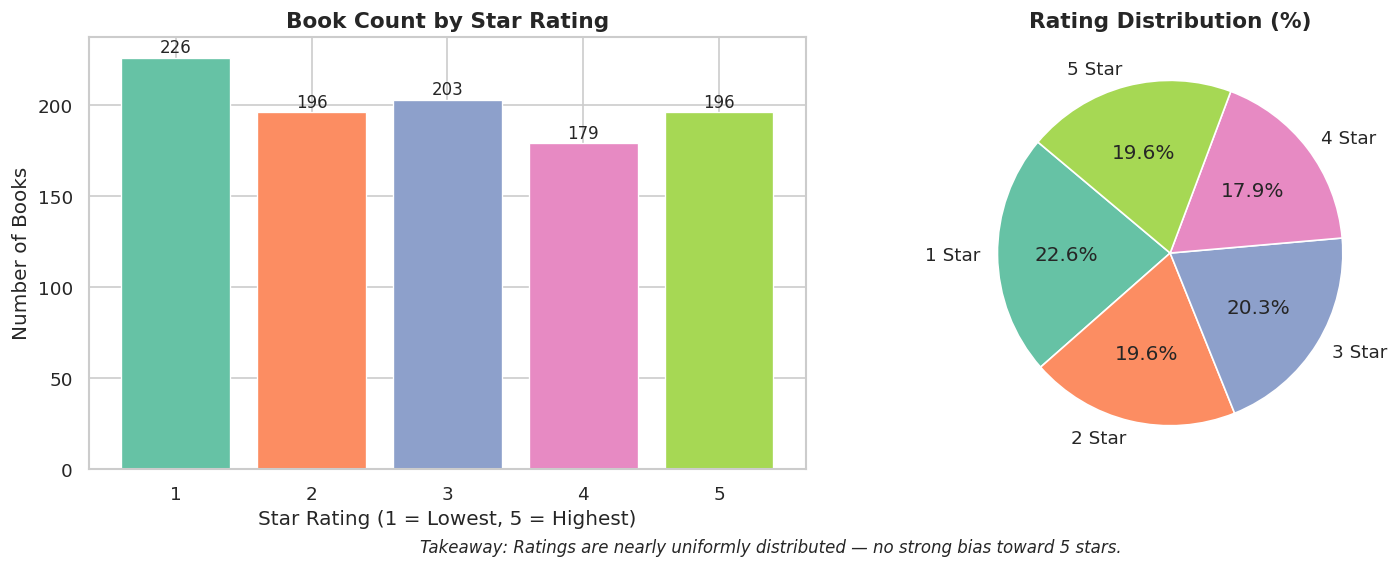

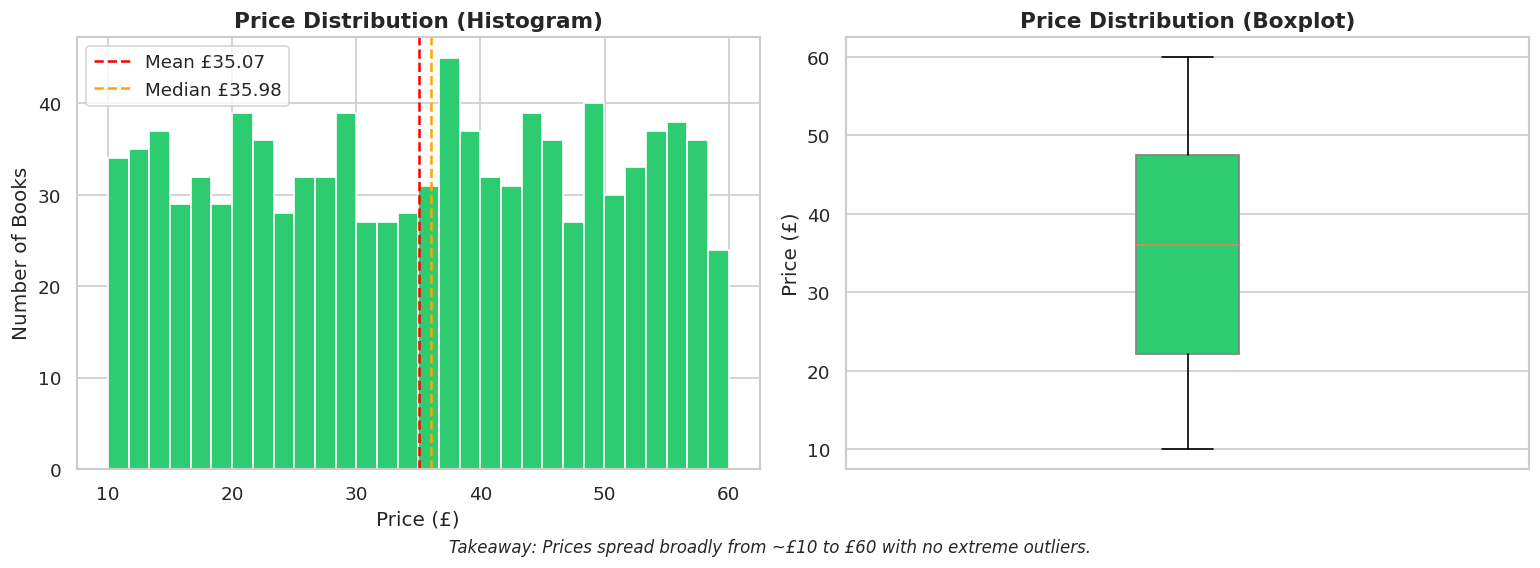

/tmp/ipykernel_54516/2312827691.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


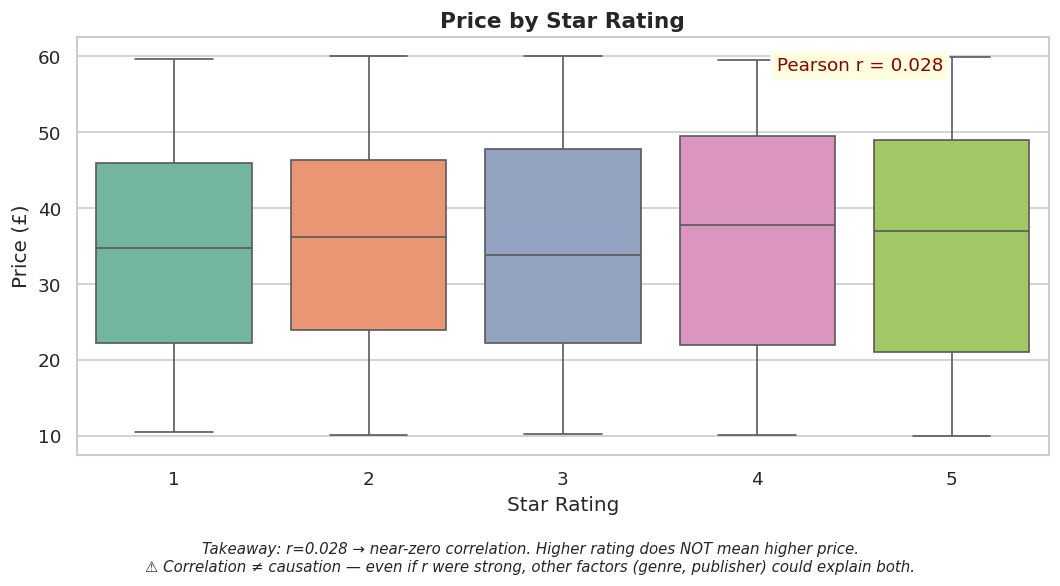

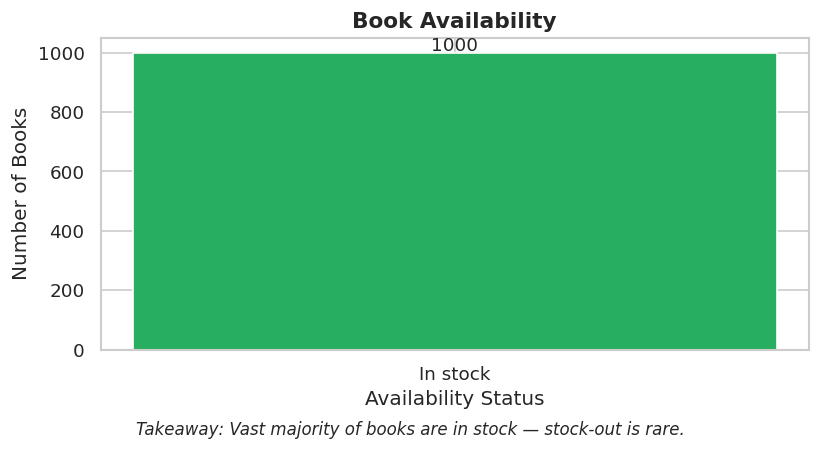


  EDA COMPLETE — KEY FINDINGS
  1. Dataset       : 1000 books, 4 columns, 0 nulls
  2. Avg price     : £35.07 | Median: £35.98
  3. Rating dist.  : Roughly uniform across 1–5 stars
  4. Price-Rating r: 0.028 → no meaningful correlation
  5. Availability  : 1000 in stock / 0 out of stock

  Charts saved: chart_rating_distribution.png,
                chart_price_distribution.png,
                chart_price_by_rating.png,
                chart_availability.png


In [2]:
# ============================================================
# TASK 2: Exploratory Data Analysis (EDA)
# Dataset: books_data.csv (1000 books)
# Tool: pandas, matplotlib, seaborn
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ── Constants ────────────────────────────────────────────────
DATA_FILE = "books_data.csv"

# ============================================================
# SECTION 1: Load & Inspect
# ============================================================
df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

print("=" * 55)
print("  SECTION 1 — STRUCTURE & DATA TYPES")
print("=" * 55)
print(f"  Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns      : {list(df.columns)}")
print(f"\n  Data types:\n{df.dtypes}")
print(f"\n  First 5 rows:\n{df.head()}")

# ============================================================
# SECTION 2: Missing Values & Duplicates
# ============================================================
print("\n" + "=" * 55)
print("  SECTION 2 — MISSING VALUES & DUPLICATES")
print("=" * 55)

null_counts = df.isnull().sum()
dup_count   = df.duplicated().sum()

print(f"  Null values per column:\n{null_counts}")
print(f"\n  Duplicate rows: {dup_count}")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  → {dup_count} duplicate(s) removed. New shape: {df.shape}")
else:
    print("  → No duplicates found. Dataset is clean.")

# ============================================================
# SECTION 3: Descriptive Statistics
# ============================================================
print("\n" + "=" * 55)
print("  SECTION 3 — DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df.describe().round(2))

print("\n  Key observations:")
print(f"  • Avg price       : £{df['price_gbp'].mean():.2f}")
print(f"  • Median price    : £{df['price_gbp'].median():.2f}")
print(f"  • Price std dev   : £{df['price_gbp'].std():.2f}")
print(f"  • Avg rating      : {df['rating'].mean():.2f} / 5")
print(f"  • Rating mode     : {df['rating'].mode()[0]} / 5")
print(f"  • In stock books  : {(df['availability'] == 'In stock').sum()}")
print(f"  • Out of stock    : {(df['availability'] != 'In stock').sum()}")
print()
print("  ⚠ Note: mean vs median price gap indicates right skew.")
print("  ⚠ Correlation between rating and price will be tested below.")

# ============================================================
# SECTION 4: Rating Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 4a — Rating count
rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=sns.color_palette("Set2", 5),
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_title("Book Count by Star Rating", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Star Rating (1 = Lowest, 5 = Highest)")
axes[0].set_ylabel("Number of Books")
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 3, str(v), ha="center", fontsize=10)

# Chart 4b — Rating percentage
axes[1].pie(
    rating_counts.values,
    labels=[f"{r} Star" for r in rating_counts.index],
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2", 5),
    startangle=140
)
axes[1].set_title("Rating Distribution (%)", fontsize=13, fontweight="bold")

plt.suptitle(
    "Takeaway: Ratings are nearly uniformly distributed — no strong bias toward 5 stars.",
    fontsize=10, style="italic", y=0.02
)
plt.tight_layout()
plt.savefig("chart_rating_distribution.png", bbox_inches="tight")
plt.show()

# ============================================================
# SECTION 5: Price Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 5a — Histogram
axes[0].hist(df["price_gbp"], bins=30, color="#2ecc71", edgecolor="white")
axes[0].axvline(df["price_gbp"].mean(),   color="red",    linestyle="--", label=f"Mean £{df['price_gbp'].mean():.2f}")
axes[0].axvline(df["price_gbp"].median(), color="orange", linestyle="--", label=f"Median £{df['price_gbp'].median():.2f}")
axes[0].set_title("Price Distribution (Histogram)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of Books")
axes[0].legend()

# Chart 5b — Boxplot
axes[1].boxplot(df["price_gbp"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#2ecc71", color="gray"))
axes[1].set_title("Price Distribution (Boxplot)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (£)")
axes[1].set_xticks([])

plt.suptitle(
    "Takeaway: Prices spread broadly from ~£10 to £60 with no extreme outliers.",
    fontsize=10, style="italic", y=0.02
)
plt.tight_layout()
plt.savefig("chart_price_distribution.png", bbox_inches="tight")
plt.show()

# ============================================================
# SECTION 6: Price by Rating
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="rating",
    y="price_gbp",
    palette="Set2",
    ax=ax
)
ax.set_title("Price by Star Rating", fontsize=13, fontweight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Price (£)")

corr = df["price_gbp"].corr(df["rating"])
ax.annotate(
    f"Pearson r = {corr:.3f}",
    xy=(0.72, 0.92), xycoords="axes fraction",
    fontsize=11, color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow")
)

plt.suptitle(
    f"Takeaway: r={corr:.3f} → near-zero correlation. "
    "Higher rating does NOT mean higher price.\n"
    "⚠ Correlation ≠ causation — even if r were strong, "
    "other factors (genre, publisher) could explain both.",
    fontsize=9, style="italic", y=-0.01
)
plt.tight_layout()
plt.savefig("chart_price_by_rating.png", bbox_inches="tight")
plt.show()

# ============================================================
# SECTION 7: Availability Analysis
# ============================================================
avail_counts = df["availability"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(avail_counts.index, avail_counts.values,
       color=["#27ae60", "#e74c3c"], edgecolor="white")
ax.set_title("Book Availability", fontsize=13, fontweight="bold")
ax.set_xlabel("Availability Status")
ax.set_ylabel("Number of Books")
for i, v in enumerate(avail_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=11)

plt.suptitle(
    "Takeaway: Vast majority of books are in stock — stock-out is rare.",
    fontsize=10, style="italic", y=0.02
)
plt.tight_layout()
plt.savefig("chart_availability.png", bbox_inches="tight")
plt.show()

# ============================================================
# SECTION 8: EDA Summary
# ============================================================
print("\n" + "=" * 55)
print("  EDA COMPLETE — KEY FINDINGS")
print("=" * 55)
print(f"  1. Dataset       : 1000 books, 4 columns, 0 nulls")
print(f"  2. Avg price     : £{df['price_gbp'].mean():.2f} | Median: £{df['price_gbp'].median():.2f}")
print(f"  3. Rating dist.  : Roughly uniform across 1–5 stars")
print(f"  4. Price-Rating r: {corr:.3f} → no meaningful correlation")
print(f"  5. Availability  : {(df['availability']=='In stock').sum()} in stock / "
      f"{(df['availability']!='In stock').sum()} out of stock")
print("\n  Charts saved: chart_rating_distribution.png,")
print("                chart_price_distribution.png,")
print("                chart_price_by_rating.png,")
print("                chart_availability.png")

  [✓] Saved: viz1_rating_bar.png


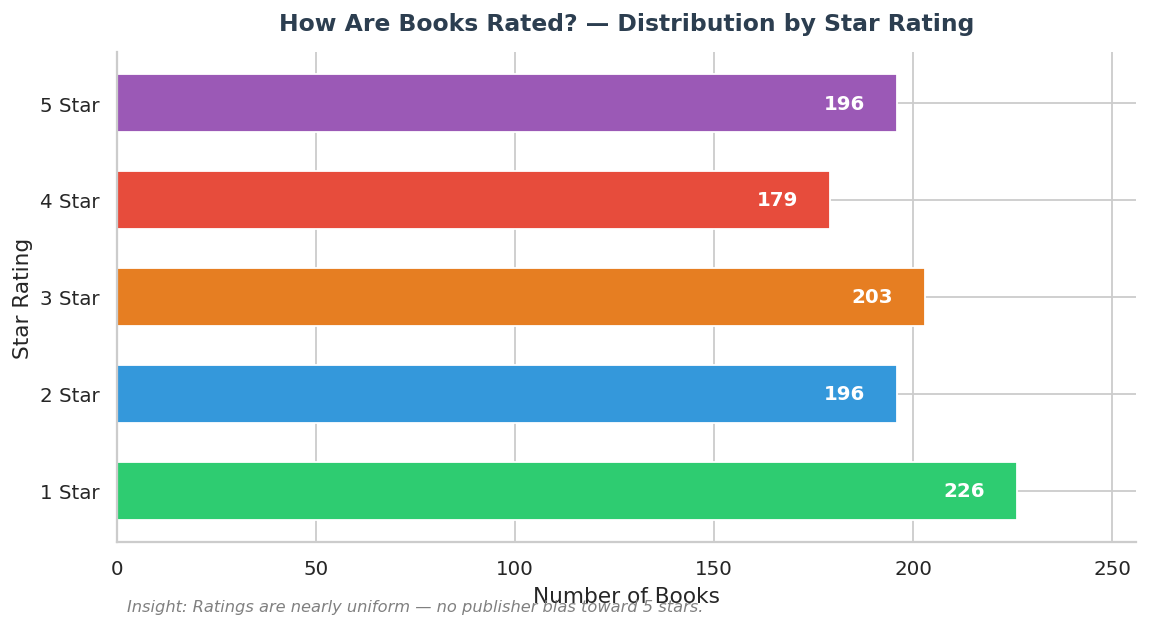

  [✓] Saved: viz2_price_kde.png


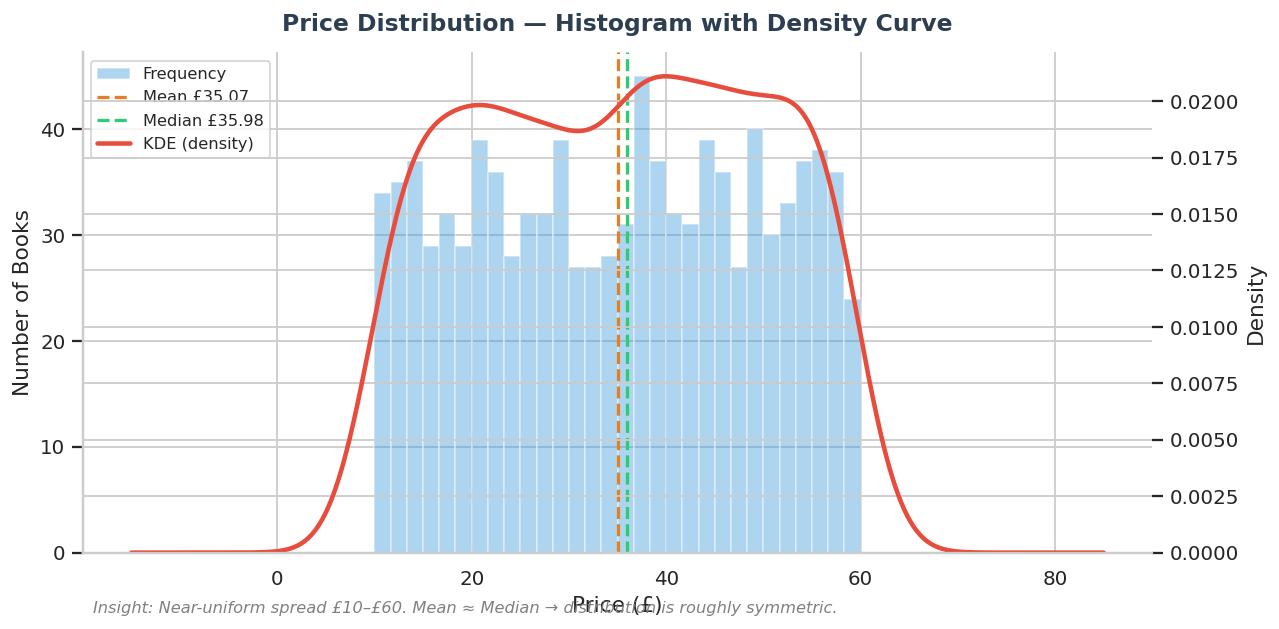

  [✓] Saved: viz3_avg_price_rating.png


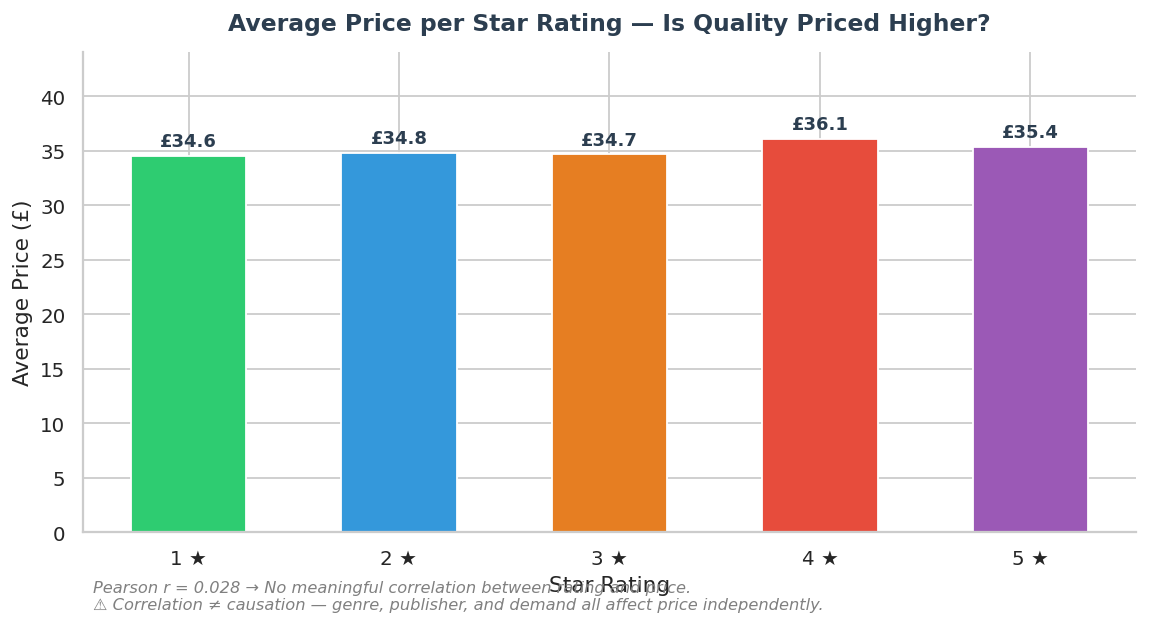

/tmp/ipykernel_54516/3664697840.py:180: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["price_bucket", "rating"])


  [✓] Saved: viz4_rating_by_price_bucket.png


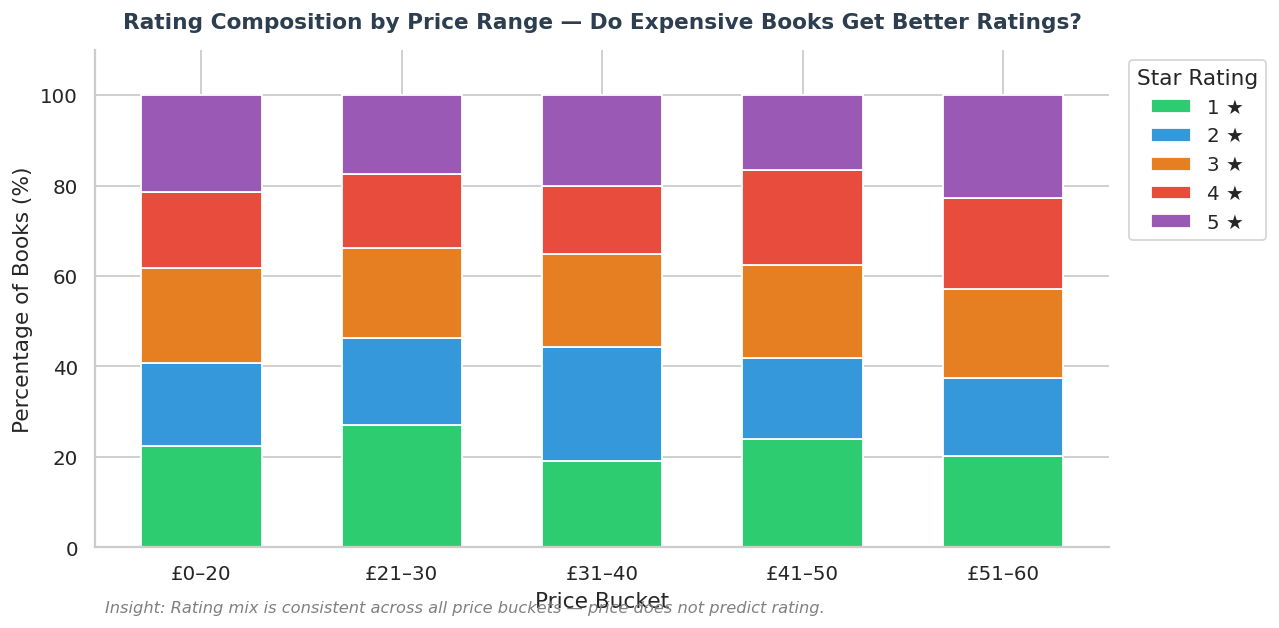

  [✓] Saved: viz5_violin_price_rating.png


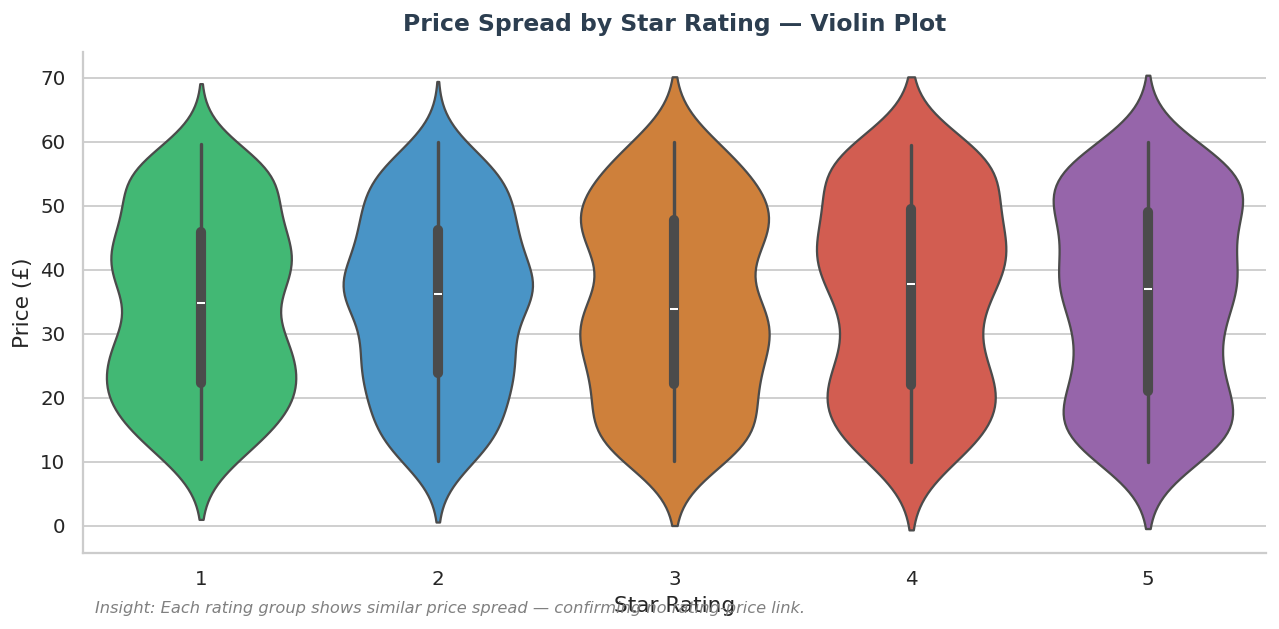

/tmp/ipykernel_54516/3664697840.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [✓] Saved: viz6_dashboard.png


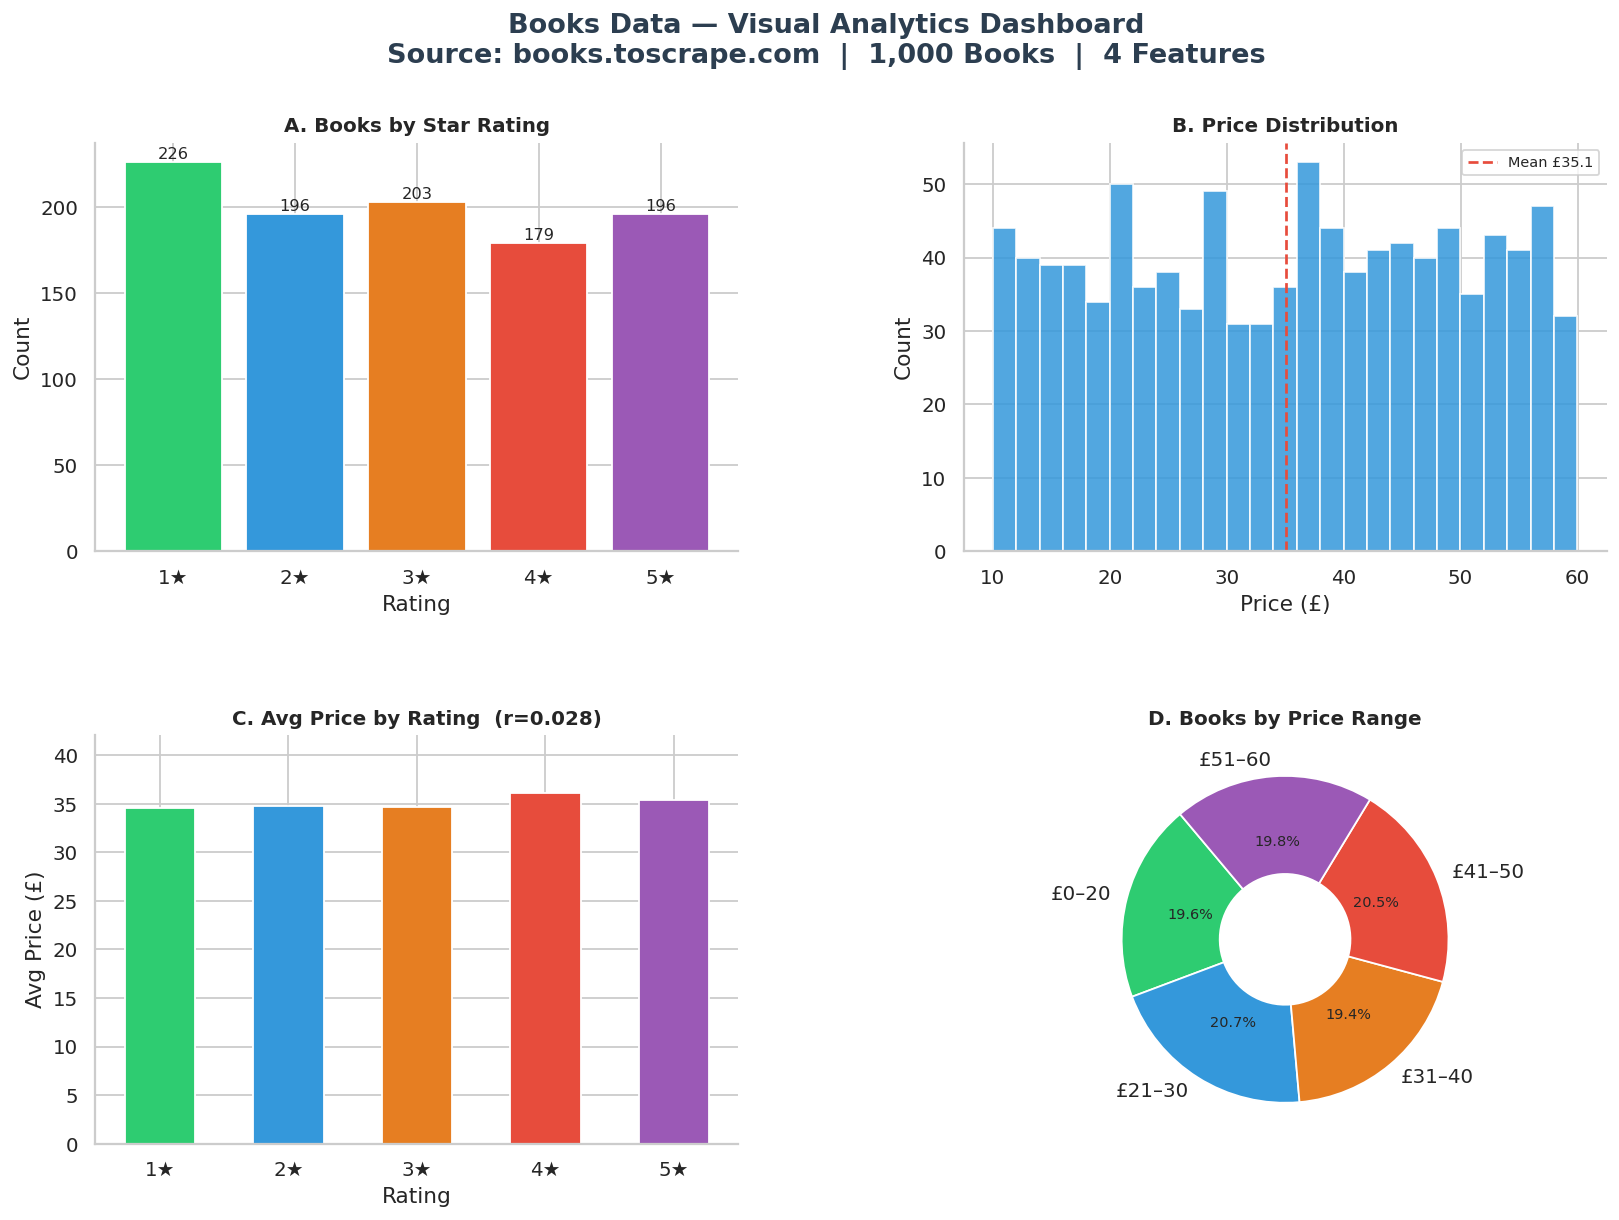


  TASK 3 COMPLETE — ALL CHARTS SAVED
  • viz1_rating_bar.png      → Rating distribution (horizontal bar)
  • viz2_price_kde.png       → Price histogram + KDE curve
  • viz3_avg_price_rating.png→ Avg price per rating (bar)
  • viz4_rating_by_price_bucket.png → Stacked % bar by price range
  • viz5_violin_price_rating.png    → Violin plot by rating
  • viz6_dashboard.png       → 4-panel summary dashboard

  KEY STORY:
  • Ratings: uniform — no platform bias
  • Prices : roughly symmetric, £10–£60
  • Rating vs Price: r=0.028 → no correlation
  ⚠ Correlation ≠ causation — always.


In [3]:
# ============================================================
# TASK 3: Data Visualization — books.toscrape.com
# Dataset: books_data.csv (1000 books)
# Tool: pandas, matplotlib, seaborn
# Output: 6 individual charts + 1 dashboard PNG
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from pathlib import Path

# ── Style & Constants ─────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]      = 130
plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

DATA_FILE   = "books_data.csv"
PALETTE     = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c", "#9b59b6"]
ACCENT      = "#2c3e50"


# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

# Derived columns
df["price_bucket"] = pd.cut(
    df["price_gbp"],
    bins=[0, 20, 30, 40, 50, 60],
    labels=["£0–20", "£21–30", "£31–40", "£41–50", "£51–60"]
)
df["rating_label"] = df["rating"].map(
    {1: "★ (1)", 2: "★★ (2)", 3: "★★★ (3)", 4: "★★★★ (4)", 5: "★★★★★ (5)"}
)

rating_counts = df["rating"].value_counts().sort_index()
bucket_counts = df["price_bucket"].value_counts().sort_index()
avg_price_by_rating = (
    df.groupby("rating")["price_gbp"]
    .mean()
    .reset_index()
    .rename(columns={"price_gbp": "avg_price"})
)


# ── Helper: save chart ────────────────────────────────────────
def save_chart(fig: plt.Figure, filename: str) -> None:
    """Save figure to PNG with tight layout."""
    fig.savefig(filename, bbox_inches="tight", facecolor="white")
    print(f"  [✓] Saved: {filename}")


# ============================================================
# CHART 1 — Horizontal Bar: Book Count by Rating
# ============================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.barh(
    [f"{r} Star" for r in rating_counts.index],
    rating_counts.values,
    color=PALETTE,
    edgecolor="white",
    height=0.6
)

# Value labels inside bars
for bar, val in zip(bars, rating_counts.values):
    ax1.text(
        bar.get_width() - 8, bar.get_y() + bar.get_height() / 2,
        str(val), va="center", ha="right",
        color="white", fontweight="bold", fontsize=11
    )

ax1.set_title("How Are Books Rated? — Distribution by Star Rating",
              fontsize=13, fontweight="bold", color=ACCENT, pad=12)
ax1.set_xlabel("Number of Books")
ax1.set_ylabel("Star Rating")
ax1.set_xlim(0, max(rating_counts.values) + 30)

ax1.annotate(
    "Insight: Ratings are nearly uniform — no publisher bias toward 5 stars.",
    xy=(0.01, -0.14), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)

plt.tight_layout()
save_chart(fig1, "viz1_rating_bar.png")
plt.show()


# ============================================================
# CHART 2 — KDE + Histogram: Price Distribution
# ============================================================
fig2, ax2 = plt.subplots(figsize=(10, 5))

ax2.hist(df["price_gbp"], bins=30, color="#3498db",
         alpha=0.4, edgecolor="white", label="Frequency")

ax2_twin = ax2.twinx()
df["price_gbp"].plot.kde(ax=ax2_twin, color="#e74c3c",
                         linewidth=2.5, label="KDE (density)")

ax2.axvline(df["price_gbp"].mean(),   color="#e67e22", linestyle="--",
            linewidth=1.8, label=f"Mean £{df['price_gbp'].mean():.2f}")
ax2.axvline(df["price_gbp"].median(), color="#2ecc71", linestyle="--",
            linewidth=1.8, label=f"Median £{df['price_gbp'].median():.2f}")

ax2.set_title("Price Distribution — Histogram with Density Curve",
              fontsize=13, fontweight="bold", color=ACCENT, pad=12)
ax2.set_xlabel("Price (£)")
ax2.set_ylabel("Number of Books")
ax2_twin.set_ylabel("Density")
ax2_twin.set_ylim(bottom=0)

# Combined legend from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax2.annotate(
    "Insight: Near-uniform spread £10–£60. Mean ≈ Median → distribution is roughly symmetric.",
    xy=(0.01, -0.12), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)

plt.tight_layout()
save_chart(fig2, "viz2_price_kde.png")
plt.show()


# ============================================================
# CHART 3 — Grouped Bar: Avg Price per Rating
# ============================================================
fig3, ax3 = plt.subplots(figsize=(9, 5))

bars3 = ax3.bar(
    avg_price_by_rating["rating"].astype(str) + " ★",
    avg_price_by_rating["avg_price"],
    color=PALETTE,
    edgecolor="white",
    width=0.55
)

for bar, val in zip(bars3, avg_price_by_rating["avg_price"]):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"£{val:.1f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color=ACCENT
    )

ax3.set_ylim(0, avg_price_by_rating["avg_price"].max() + 8)
ax3.set_title("Average Price per Star Rating — Is Quality Priced Higher?",
              fontsize=13, fontweight="bold", color=ACCENT, pad=12)
ax3.set_xlabel("Star Rating")
ax3.set_ylabel("Average Price (£)")

corr = df["price_gbp"].corr(df["rating"])
ax3.annotate(
    f"Pearson r = {corr:.3f} → No meaningful correlation between rating and price.\n"
    "⚠ Correlation ≠ causation — genre, publisher, and demand all affect price independently.",
    xy=(0.01, -0.16), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)

plt.tight_layout()
save_chart(fig3, "viz3_avg_price_rating.png")
plt.show()


# ============================================================
# CHART 4 — Stacked Bar: Rating Composition by Price Bucket
# ============================================================
pivot = (
    df.groupby(["price_bucket", "rating"])
    .size()
    .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig4, ax4 = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(pivot_pct))
for i, col in enumerate(pivot_pct.columns):
    ax4.bar(
        pivot_pct.index.astype(str),
        pivot_pct[col],
        bottom=bottom,
        label=f"{col} ★",
        color=PALETTE[i],
        edgecolor="white",
        width=0.6
    )
    bottom += pivot_pct[col].values

ax4.set_title("Rating Composition by Price Range — Do Expensive Books Get Better Ratings?",
              fontsize=12, fontweight="bold", color=ACCENT, pad=12)
ax4.set_xlabel("Price Bucket")
ax4.set_ylabel("Percentage of Books (%)")
ax4.set_ylim(0, 110)
ax4.legend(title="Star Rating", bbox_to_anchor=(1.01, 1), loc="upper left")

ax4.annotate(
    "Insight: Rating mix is consistent across all price buckets — price does not predict rating.",
    xy=(0.01, -0.13), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)

plt.tight_layout()
save_chart(fig4, "viz4_rating_by_price_bucket.png")
plt.show()


# ============================================================
# CHART 5 — Violin Plot: Price Distribution by Rating
# ============================================================
fig5, ax5 = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="rating",
    y="price_gbp",
    hue="rating",
    palette=PALETTE,
    inner="box",
    legend=False,
    ax=ax5
)

ax5.set_title("Price Spread by Star Rating — Violin Plot",
              fontsize=13, fontweight="bold", color=ACCENT, pad=12)
ax5.set_xlabel("Star Rating")
ax5.set_ylabel("Price (£)")

ax5.annotate(
    "Insight: Each rating group shows similar price spread — confirming no rating-price link.",
    xy=(0.01, -0.12), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)

plt.tight_layout()
save_chart(fig5, "viz5_violin_price_rating.png")
plt.show()


# ============================================================
# CHART 6 — Dashboard: Summary Panel (2×2 grid)
# ============================================================
fig6 = plt.figure(figsize=(15, 10))
fig6.suptitle(
    "Books Data — Visual Analytics Dashboard\n"
    "Source: books.toscrape.com  |  1,000 Books  |  4 Features",
    fontsize=15, fontweight="bold", color=ACCENT, y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig6, hspace=0.45, wspace=0.35)

# Panel A — Rating bar
ax_a = fig6.add_subplot(gs[0, 0])
ax_a.bar(
    [f"{r}★" for r in rating_counts.index],
    rating_counts.values,
    color=PALETTE, edgecolor="white"
)
ax_a.set_title("A. Books by Star Rating", fontweight="bold", fontsize=11)
ax_a.set_xlabel("Rating")
ax_a.set_ylabel("Count")
for i, v in enumerate(rating_counts.values):
    ax_a.text(i, v + 2, str(v), ha="center", fontsize=9)

# Panel B — Price histogram
ax_b = fig6.add_subplot(gs[0, 1])
ax_b.hist(df["price_gbp"], bins=25, color="#3498db", edgecolor="white", alpha=0.85)
ax_b.axvline(df["price_gbp"].mean(), color="#e74c3c",
             linestyle="--", linewidth=1.5, label=f"Mean £{df['price_gbp'].mean():.1f}")
ax_b.set_title("B. Price Distribution", fontweight="bold", fontsize=11)
ax_b.set_xlabel("Price (£)")
ax_b.set_ylabel("Count")
ax_b.legend(fontsize=8)

# Panel C — Avg price per rating
ax_c = fig6.add_subplot(gs[1, 0])
ax_c.bar(
    avg_price_by_rating["rating"].astype(str) + "★",
    avg_price_by_rating["avg_price"],
    color=PALETTE, edgecolor="white", width=0.55
)
ax_c.set_title(f"C. Avg Price by Rating  (r={corr:.3f})",
               fontweight="bold", fontsize=11)
ax_c.set_xlabel("Rating")
ax_c.set_ylabel("Avg Price (£)")
ax_c.set_ylim(0, avg_price_by_rating["avg_price"].max() + 6)

# Panel D — Price bucket donut
ax_d = fig6.add_subplot(gs[1, 1])
wedges, texts, autotexts = ax_d.pie(
    bucket_counts.values,
    labels=bucket_counts.index.astype(str),
    autopct="%1.1f%%",
    colors=PALETTE,
    startangle=130,
    wedgeprops=dict(width=0.6)          # donut effect
)
for at in autotexts:
    at.set_fontsize(8)
ax_d.set_title("D. Books by Price Range", fontweight="bold", fontsize=11)

plt.tight_layout()
save_chart(fig6, "viz6_dashboard.png")
plt.show()


# ── Final summary ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TASK 3 COMPLETE — ALL CHARTS SAVED")
print("=" * 55)
saved = [
    "viz1_rating_bar.png      → Rating distribution (horizontal bar)",
    "viz2_price_kde.png       → Price histogram + KDE curve",
    "viz3_avg_price_rating.png→ Avg price per rating (bar)",
    "viz4_rating_by_price_bucket.png → Stacked % bar by price range",
    "viz5_violin_price_rating.png    → Violin plot by rating",
    "viz6_dashboard.png       → 4-panel summary dashboard",
]
for s in saved:
    print(f"  • {s}")
print()
print("  KEY STORY:")
print("  • Ratings: uniform — no platform bias")
print("  • Prices : roughly symmetric, £10–£60")
print(f"  • Rating vs Price: r={corr:.3f} → no correlation")
print("  ⚠ Correlation ≠ causation — always.")